In [ ]:
# Globals
import numpy as np

from shared_util.pipelines import ModelPipeline
import warnings
warnings.filterwarnings('ignore')

METRICS_DB_ID = 16
METRICS_NOTES = "adj effectiveness"
PCA = False
scaler = 'standard' # 'standard' for StandardScaler or 'power' for PowerTransformer (yeo-johnson)

R = 16_300 # Average cost of readmission (Jiang and Hensche, 2023) 
e = 0.33 # estimated program effectiveness - estimate 33% for target cohort, studies show >50%, unknown readmission cause, no study on target cohort, so lowered
m_cost_list = [150, 220, 330, 440, 660, 1000] # program costs 30-60 days, $150-$220 per patient per month
COST_PREF = 330 # 1 month monitoring cost


UPDATE_DATABASE = False # keep false in notebooks, will crash
GET_BASELINE = False    # controls if a baseline smote vs undersample is done for this run
SHOW_FEAT_IMPORTANCE = True # controls if feature importance is shown for this run
USE_PRE_COMPUTED_HYPERPARAMS = True # controls if hyperparam sweep is run or to use hyperparams from previous runs

LOG_TRANSFORM_COLS = np.array(
    ['num_medications', 'num_procedures', 'time_in_hospital', 'number_inpatient'
     ])

# Results

In [5]:
from shared_util.fetch import fetch_metric, fetch_all_metrics
import pandas as pd
from shared_util.pd_util import filter_df

metrics_df = filter_df(fetch_all_metrics())

pca_ = filter_df(metrics_df, run_id=2)
log_scale_ = filter_df(metrics_df, run_id=1)
pt_ = filter_df(metrics_df, run_id=3)
pt_log = filter_df(metrics_df, run_id=4)
bin_v2 = filter_df(metrics_df, run_id=5)
bin_v3 = filter_df(metrics_df, run_id=6)

# pca_results_df = fetch_metric(run_id=2)
# results_df = fetch_metric(run_id=1)

# pt_df = fetch_metric(run_id=3)

# pt_log_df = fetch_metric(run_id=4)

# new_bin = fetch_metric(run_id=5)

# bin_3 = fetch_metric(run_id=6)



test_df = filter_df(metrics_df, data=['test'])


most_recent_df = filter_df(metrics_df, run_id=[METRICS_DB_ID])


filter_df(most_recent_df, data='test').head(5)

,id,run_id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,tn,tp,fp,fn,est_pp_savings,created_at
0,257,16,xgb,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,adj effectiveness,0.676026,0.208970,0.105172,0.950478,0.189388,1380.0,1094.0,9308.0,57.0,225.353475,2025-10-30 15:17:33.349297
6,251,16,rf,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,adj effectiveness,0.674651,0.207365,0.104980,0.950478,0.189077,1361.0,1094.0,9327.0,57.0,226.859400,2025-10-30 15:16:51.705906
2,255,16,svc,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,adj effectiveness,0.674149,0.217417,0.105734,0.945265,0.190193,1486.0,1088.0,9202.0,63.0,226.828893,2025-10-30 15:17:30.303414
4,253,16,sgd,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,adj effectiveness,0.669408,0.244024,0.106786,0.920070,0.191362,1830.0,1059.0,8858.0,92.0,231.759896,2025-10-30 15:16:55.263046


In [33]:
filter_df(metrics_df, run_id=[12], data=['test']).head(5) # 50% plan effectiveness

,id,run_id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,tn,tp,fp,fn,est_pp_savings,created_at
24,205,12,xgb,test,cost_opt_R=16300_e=0.50_c=440,under_sample,tuned_best_roc_auc,????,0.676026,0.159304,0.101575,0.974805,0.183980,764.0,1122.0,9924.0,29.0,397.324145,2025-10-29 22:22:55.632630
30,199,12,rf,test,cost_opt_R=16300_e=0.50_c=440,under_sample,tuned_best_roc_auc,????,0.674651,0.207365,0.104980,0.950478,0.189077,1361.0,1094.0,9327.0,57.0,396.999748,2025-10-29 22:10:00.485321
26,203,12,svc,test,cost_opt_R=16300_e=0.50_c=440,under_sample,tuned_best_roc_auc,????,0.674149,0.217417,0.105734,0.945265,0.190193,1486.0,1088.0,9202.0,63.0,396.383730,2025-10-29 22:22:19.851821
28,201,12,sgd,test,cost_opt_R=16300_e=0.50_c=440,under_sample,tuned_best_roc_auc,????,0.669408,0.244024,0.106786,0.920070,0.191362,1830.0,1059.0,8858.0,92.0,401.807715,2025-10-29 22:10:45.245702


### Comparing Different runs

In [6]:
from shared_util.pd_util import filter_df

results_df = filter_df(test_df, model=['xgb', 'svc', 'sgd', 'rf'], run_id=[12, 13, 14,15, 16])



#df = pd.concat([pca_results_df, results_df, pt_df, pt_log_df, new_bin, bin_3], axis=0)

run_notes = pd.DataFrame({
    "run_id": [12, 13, 14, 15, 16],
    "label": ['c=440,e=0.50','c=440,e=0.25','c=330,e=0.25','c=330,e=0.45', 'c=330,e=0.33']
})


#df_test = filter_df(df, data=['test'])
df_means = results_df.groupby('run_id', as_index=False).mean(numeric_only=True)

df_label = df_means.merge(run_notes, on='run_id', how='left')


=== Overall ranking (by rank_sum -> overall_score) ===


,run_id,label,overall_score,rank_sum,roc_auc,f1,precision,recall,accuracy
0,13,"c=440,e=0.25",0.750,9.0,0.673558,0.267766,0.182189,0.508036,0.729728
1,14,"c=330,e=0.25",0.625,11.0,0.673558,0.218237,0.126919,0.780843,0.455317
2,16,"c=330,e=0.33",0.500,13.0,0.673558,0.190005,0.105668,0.941573,0.219444
3,12,"c=440,e=0.50",0.375,15.0,0.673558,0.188653,0.104769,0.947654,0.207028
4,15,"c=330,e=0.45",0.250,17.0,0.673558,0.180886,0.099597,0.984144,0.133352



=== Top 5 by roc_auc ===


,run_id,label,roc_auc
0,13,"c=440,e=0.25",0.673558
1,14,"c=330,e=0.25",0.673558
2,16,"c=330,e=0.33",0.673558
3,12,"c=440,e=0.50",0.673558
4,15,"c=330,e=0.45",0.673558



=== Top 5 by f1 ===


...

,run_id,label,precision
0,13,"c=440,e=0.25",0.182189
1,14,"c=330,e=0.25",0.126919
2,16,"c=330,e=0.33",0.105668
3,12,"c=440,e=0.50",0.104769
4,15,"c=330,e=0.45",0.099597



=== Top 5 by recall ===


,run_id,label,recall
4,15,"c=330,e=0.45",0.984144
3,12,"c=440,e=0.50",0.947654
2,16,"c=330,e=0.33",0.941573
1,14,"c=330,e=0.25",0.780843
0,13,"c=440,e=0.25",0.508036



=== Top 5 by accuracy ===


,run_id,label,accuracy
0,13,"c=440,e=0.25",0.729728
1,14,"c=330,e=0.25",0.455317
2,16,"c=330,e=0.33",0.219444
3,12,"c=440,e=0.50",0.207028
4,15,"c=330,e=0.45",0.133352


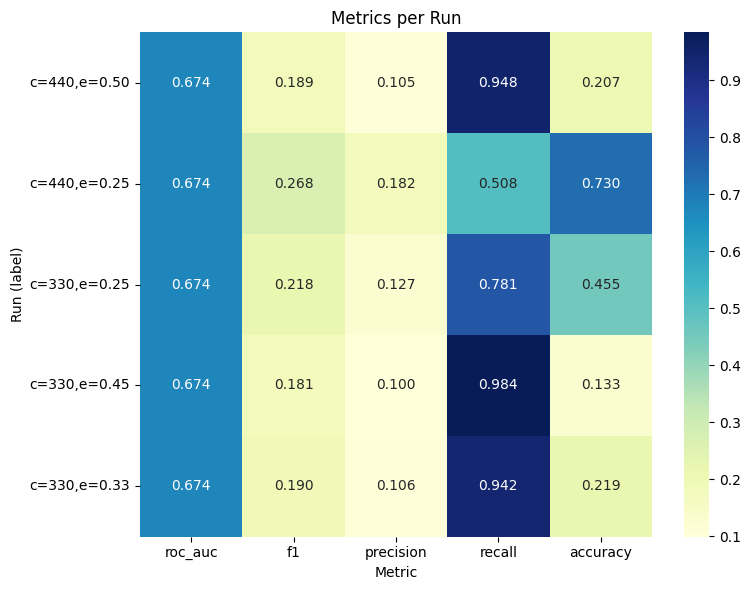

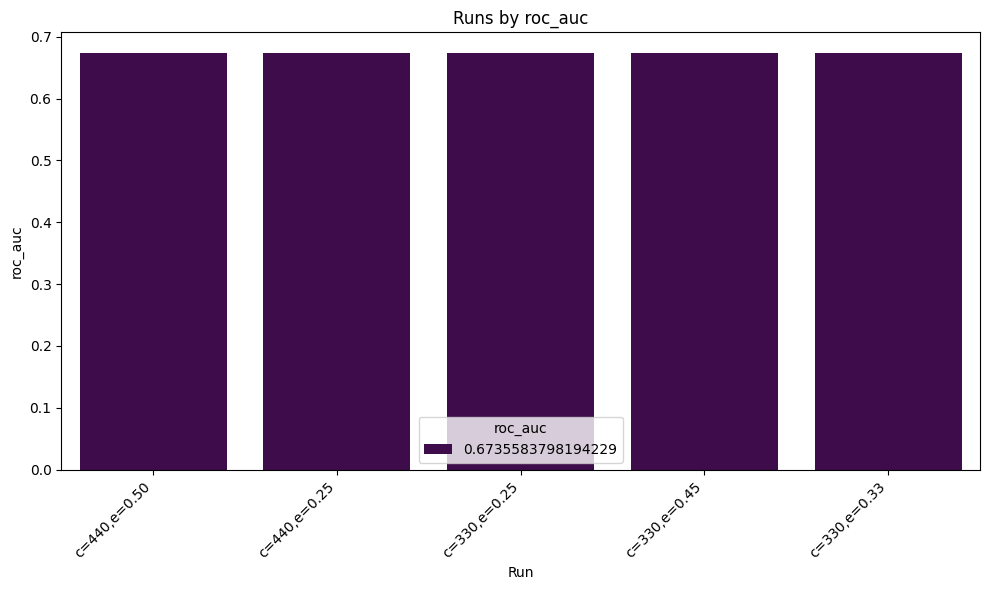

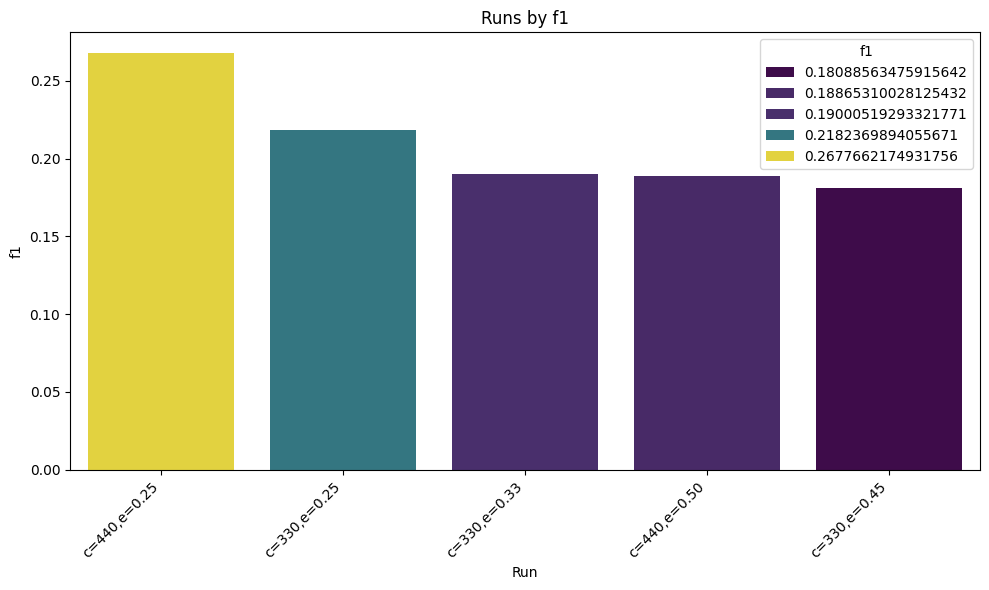

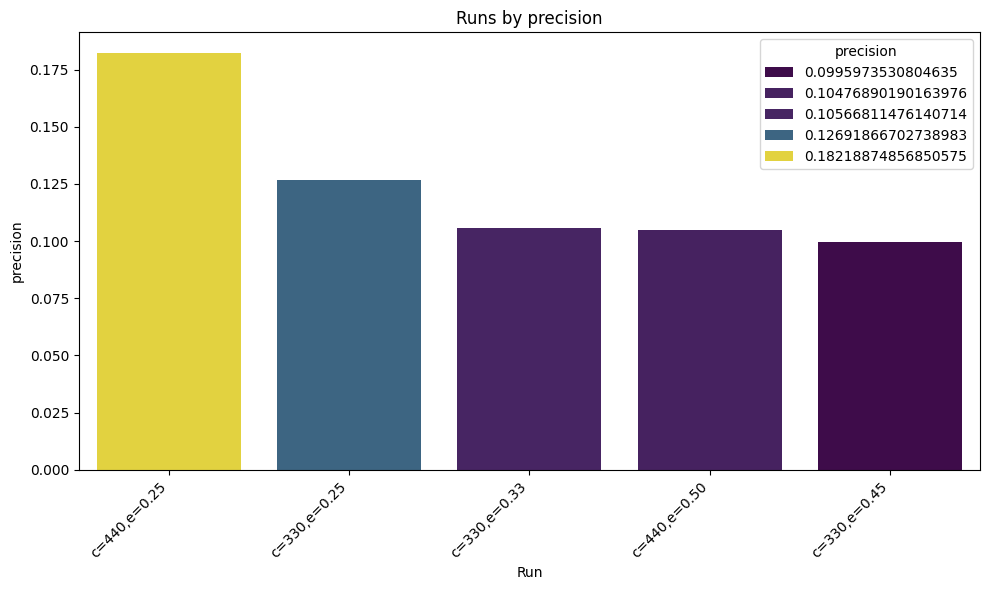

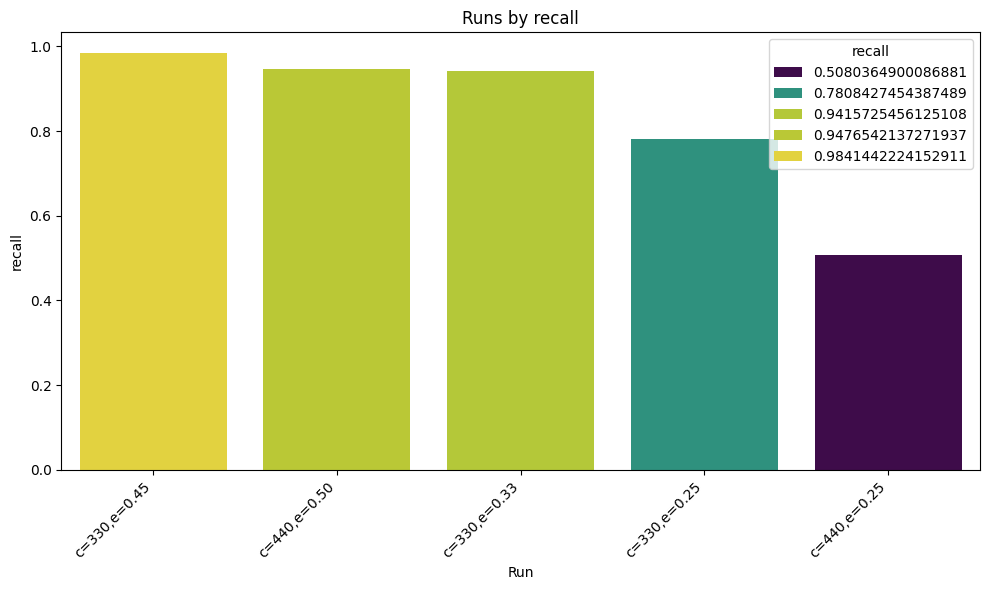

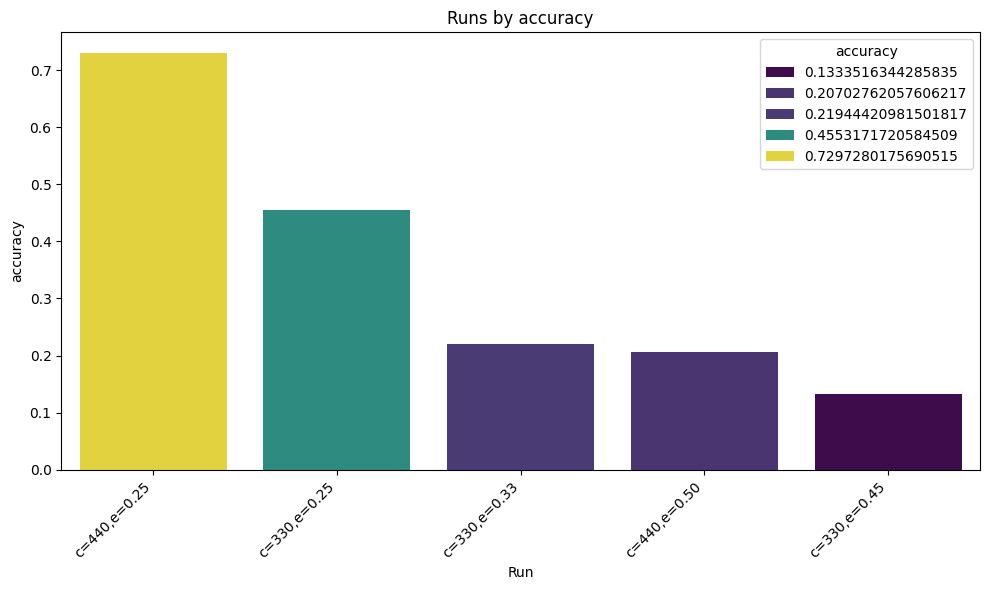

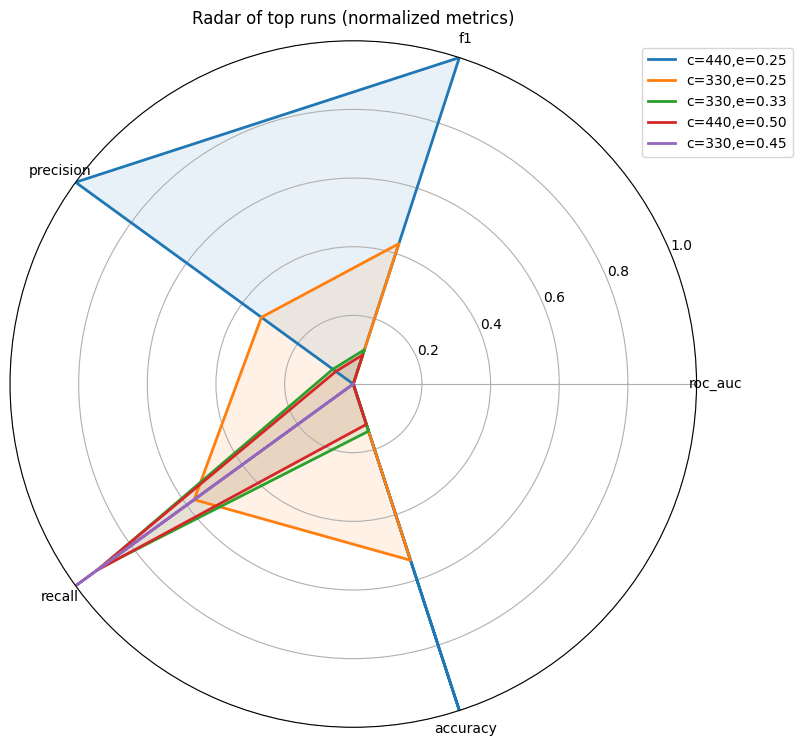

,run_id,label,roc_auc,f1,precision,recall,accuracy,rank_roc_auc,rank_f1,rank_precision,rank_recall,rank_accuracy,rank_sum,overall_score
0,13,"c=440,e=0.25",0.673558,0.267766,0.182189,0.508036,0.729728,1.0,1.0,1.0,5.0,1.0,9.0,0.750
1,14,"c=330,e=0.25",0.673558,0.218237,0.126919,0.780843,0.455317,1.0,2.0,2.0,4.0,2.0,11.0,0.625
2,16,"c=330,e=0.33",0.673558,0.190005,0.105668,0.941573,0.219444,1.0,3.0,3.0,3.0,3.0,13.0,0.500
3,12,"c=440,e=0.50",0.673558,0.188653,0.104769,0.947654,0.207028,1.0,4.0,4.0,2.0,4.0,15.0,0.375
4,15,"c=330,e=0.45",0.673558,0.180886,0.099597,0.984144,0.133352,1.0,5.0,5.0,1.0,5.0,17.0,0.250


In [7]:
from shared_util.metrics.compare import compare_runs

compare_runs(
    df=df_label,
    metric_cols=["roc_auc", "f1", "precision", "recall", "accuracy"],
)

### Comparing Models

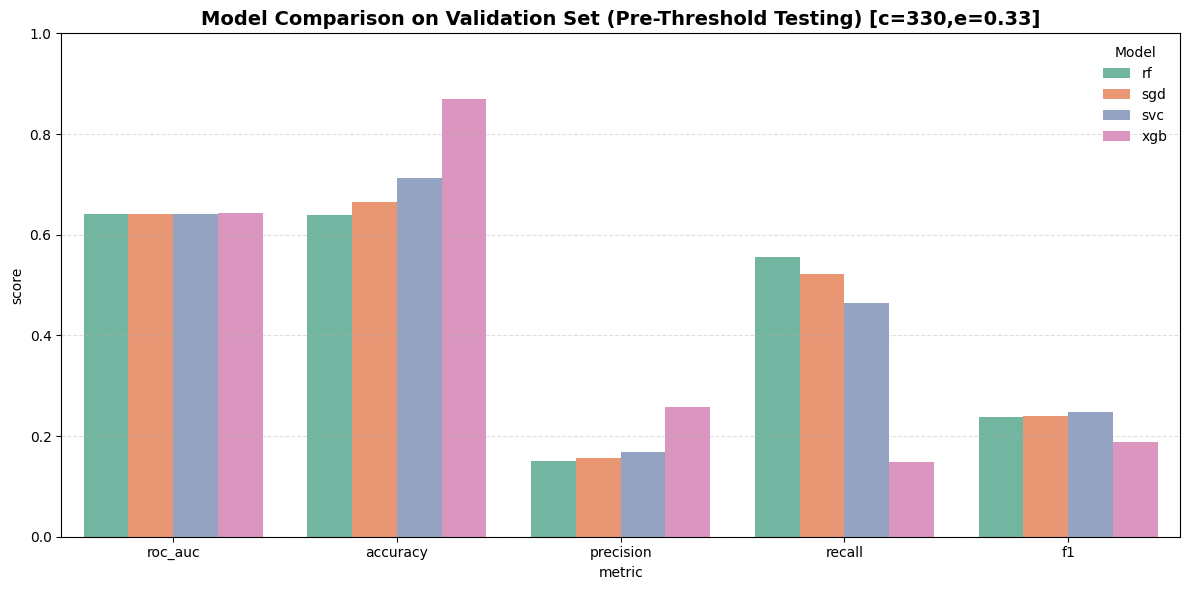

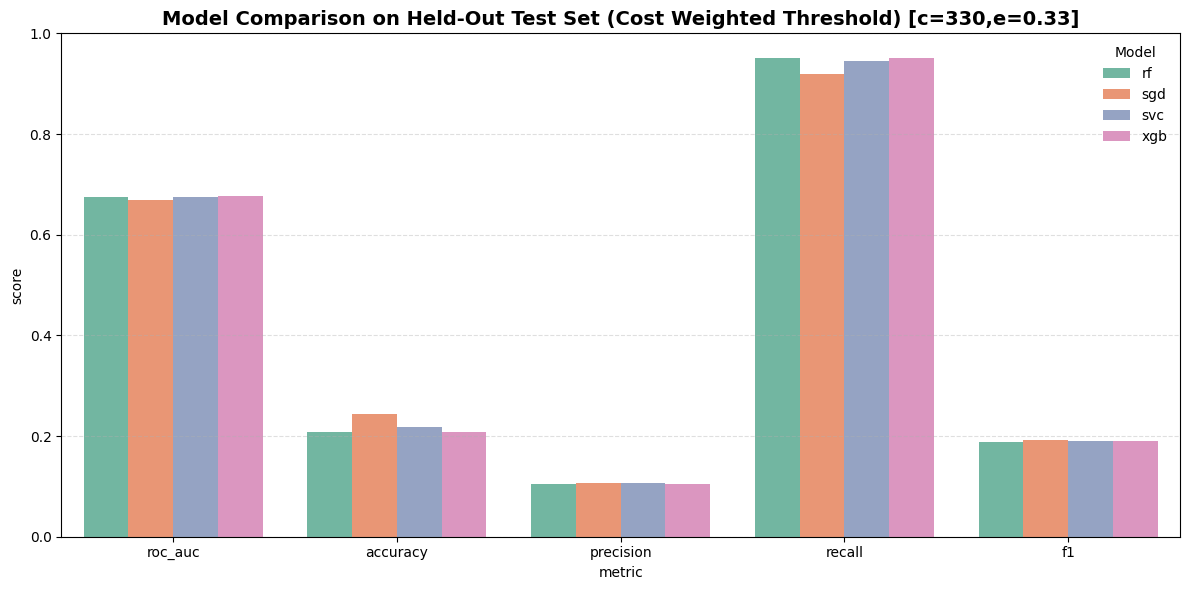

In [8]:
from shared_util.metrics.printing import summary_by
from shared_util.metrics.plotting import plot_metrics

plot_metrics(most_recent_df, METRICS_DB_ID, 'c=330,e=0.33')

In [4]:
print('--most recent--')


summary_by(most_recent_df, col='roc_auc')
summary_by(most_recent_df, col='recall')
summary_by(most_recent_df, col='precision')
summary_by(most_recent_df, col='est_pp_savings')
summary_by(most_recent_df, col='accuracy')


# print('--no pca--')
# summary_by_auc(results_df, plot_id=1)
# summary_by_recall(results_df)



--most recent--
Models by roc_auc


,model,roc_auc
0,xgb,0.676
6,rf,0.675
2,svc,0.674
4,sgd,0.669


Models by recall


,model,recall
0,xgb,0.950
6,rf,0.950
2,svc,0.945
4,sgd,0.920


Models by precision


,model,precision
4,sgd,0.107
2,svc,0.106
0,xgb,0.105
6,rf,0.105


Models by est_pp_savings


,model,est_pp_savings
4,sgd,231.760
6,rf,226.859
2,svc,226.829
0,xgb,225.353


Models by accuracy


,model,accuracy
4,sgd,0.244
2,svc,0.217
0,xgb,0.209
6,rf,0.207


### Check validation vs test roc_auc

In [36]:
_test_val = filter_df(most_recent_df, data=['test', 'validate']).groupby(by='model', as_index=False)['roc_auc'].mean()

_test_val.sort_values(by='roc_auc', ascending=False) #type: ignore

,model,roc_auc
3,xgb,0.659899
0,rf,0.657935
2,svc,0.657667
1,sgd,0.655656


### Hyperparameter Display

In [31]:
from shared_util.fetch import fetch_params_by_id
import pandas as pd
import ast
import re

h_params_df = fetch_params_by_id(run_id=10)

h_params_df.head(5)


_np_wrapper = re.compile(r"np\.(?:float|int)\d+\(([^)]+)\)")

def parse_hyperparams(text: str) -> pd.DataFrame:
    cleaned = _np_wrapper.sub(r"\1", text)
    params = ast.literal_eval(cleaned)

    def normalize(value):
        if isinstance(value, np.generic):
            return value.item()
        return value

    data = {k: normalize(v) for k, v in params.items()}
    return pd.DataFrame(data.items(), columns=["param", "value"])

for row in h_params_df.itertuples():
    print(f'Model: {row.model}')
    display(parse_hyperparams(row.hyperparam_text)) # type: ignore


Model: xgb


,param,value
0,model__subsample,0.6
1,model__scale_pos_weight,4.0
2,model__min_child_weight,2.0
3,model__max_depth,3.0
4,model__learning_rate,0.1
5,model__gamma,0.0
6,model__colsample_bytree,0.8


Model: sgd


,param,value
0,model__tol,0.0001
1,model__shuffle,True
2,model__penalty,l1
3,model__max_iter,500
4,model__loss,modified_huber
5,model__learning_rate,invscaling
6,model__l1_ratio,0.9
7,model__eta0,0.003
8,model__class_weight,None
9,model__average,10


Model: rf


,param,value
0,model__oob_score,True
1,model__n_estimators,200
2,model__min_samples_split,15
3,model__min_samples_leaf,6
4,model__max_features,log2
5,model__max_depth,10
6,model__class_weight,None
7,model__bootstrap,True


Model: svc


,param,value
0,model__C,2.397338
1,model__gamma,0.001000


# Random Forest

After reading (Liu, V. et al.) and (Mahmoud, M. et al.) I decided to begin expirementing with random forest models instead of logistic regression models.

In other studies, random forest models were shown to out perform logsitic regression and support vector models likely due to the mix of tabular, categorical, and numerical features

### Define Pipeline

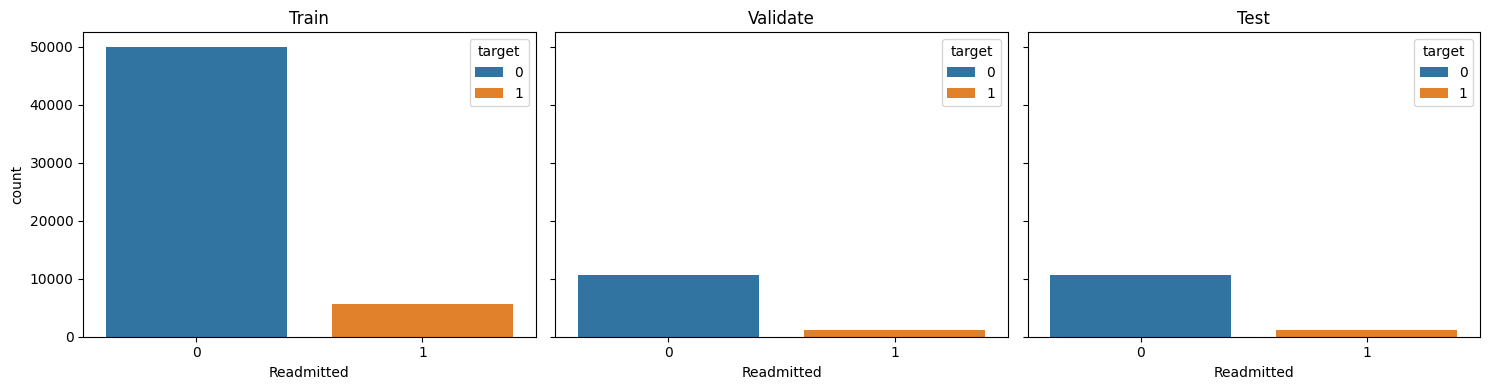

In [2]:

model = 'rf' # Random Forest


model_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,        
    data_path='cleaned',             # csv file name where the data is
    plot_y_dist=True,                # show the target distribution between splits   
    random_state=42,
    log_transform_cols=np.array([]), # no need to transform for tree models
    model=model,
    scaler=None,
    group_by_col='patient_nbr',
    create_interactions=False, # no interaction terms for tree models
    one_hot_ordinal=False, # no one-hot encoding for tree models, use int based grouping
)

### Baseline

Get a baseline before looking at feature importance or hyperparameter tuning

We can use this baseline to check class imbalance approach methods, as well as to get a sense if this model can learn anything from the engineered features

In [3]:
if GET_BASELINE:
    model_pipe.run_baseline(
        run_smote=True,
        run_undersampler=True,
        show_duration_info=True,
    )

After several iterations of data cleaning tweaks, baseline SMOTE is performing significantly better with mean ROC of ~0.59

However the random under sampler still outperforms with a mean AUC_ROC of ~0.63

SMOTE performed worse than under sampling so we will stick with under sampling going forward

A mean ROC_AUC score of 0.630 implies that the model has learned something from the data so we will continue analysis.

### Feature Importance

- Tree impurity based importance is naturaly skewed to favor continuous features
- Permutation importance is model agnostic, is uneffected by the large class imbalance, and is not effected by the under sampling technique used

In [4]:
if SHOW_FEAT_IMPORTANCE:
    model_pipe.permute_importance(
        print_num=15,
        plot=True,
        show_duration_info=True
    )

In [5]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    param_grid = {
            'model__n_estimators': [100, 200, 500],
            'model__max_depth': [None, 10, 20, 30],
            'model__min_samples_split': [2, 5, 10, 15, 20],
            'model__min_samples_leaf': [1, 2, 4, 6, 10],
            'model__max_features': ['sqrt', 'log2', 0.2, 0.5],
            'model__class_weight': [None, 'balanced'],
            'model__bootstrap': [True, False],
            'model__oob_score': [True, False]
        }

    model_pipe.run_hyperparam_search(
        hyperparam_dist=param_grid,
        param_scoring='roc_auc',
        n_iter=30,
        n_jobs=-1,
        refit=True,
        show_duration_info=True
    )

### Validate

In [6]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    model_pipe.validate(
        show_duration_info=True,
        use_local_model=True,
        oob_score = True,
        n_estimators = 200,
        min_samples_split = 15,
        min_samples_leaf = 6,
        max_features = 'log2',
        max_depth = 10,
        class_weight = None,
        bootstrap = True
    )

else:
    model_pipe.validate(
        show_duration_info=False,
        use_local_model=False
    )

Held out validation metrics: rf
ROC_AUC:     0.6412181503164449
Accuracy:      0.6385410538700731
F1 score:      0.2378167641325536
Precision:     0.1512965050732807
Recall:        0.5554635761589404

Confusion matrix:

TN: 6927, FP: 3764, FN: 537, TP: 671

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.65      0.76     10691
           1       0.15      0.56      0.24      1208

    accuracy                           0.64     11899
   macro avg       0.54      0.60      0.50     11899
weighted avg       0.85      0.64      0.71     11899

connected to database
Duration: 0 hrs, 0 mins, 3.8 secs


### Test

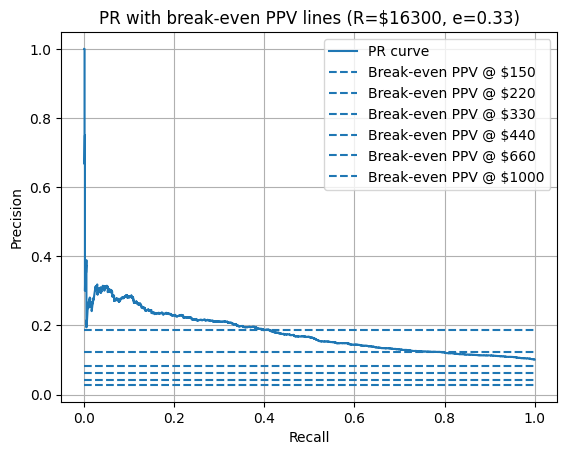

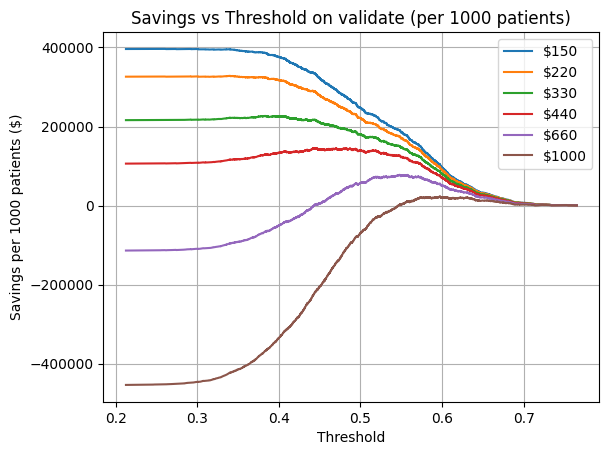

[COST] Chosen threshold: 0.3829 | PPV=0.109  Recall=0.952  FlagRate=0.888  Savings@$330=226.86 per patient
ROC_AUC:     0.6746510779483605
Accuracy:      0.2073654869499113
F1 score:      0.18907708261320427
Precision:     0.10498032818347568
Recall:        0.950477845351868

Confusion matrix:

TN: 1361, FP: 9327, FN: 57, TP: 1094

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.13      0.22     10688
           1       0.10      0.95      0.19      1151

    accuracy                           0.21     11839
   macro avg       0.53      0.54      0.21     11839
weighted avg       0.88      0.21      0.22     11839



In [7]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    model_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        oob_score = True,
        n_estimators = 200,
        min_samples_split = 15,
        min_samples_leaf = 6,
        max_features = 'log2',
        max_depth = 10,
        class_weight = None,
        bootstrap = True
    )
else:
    model_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=False,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

# Stochastic Gradient Descent Classifier

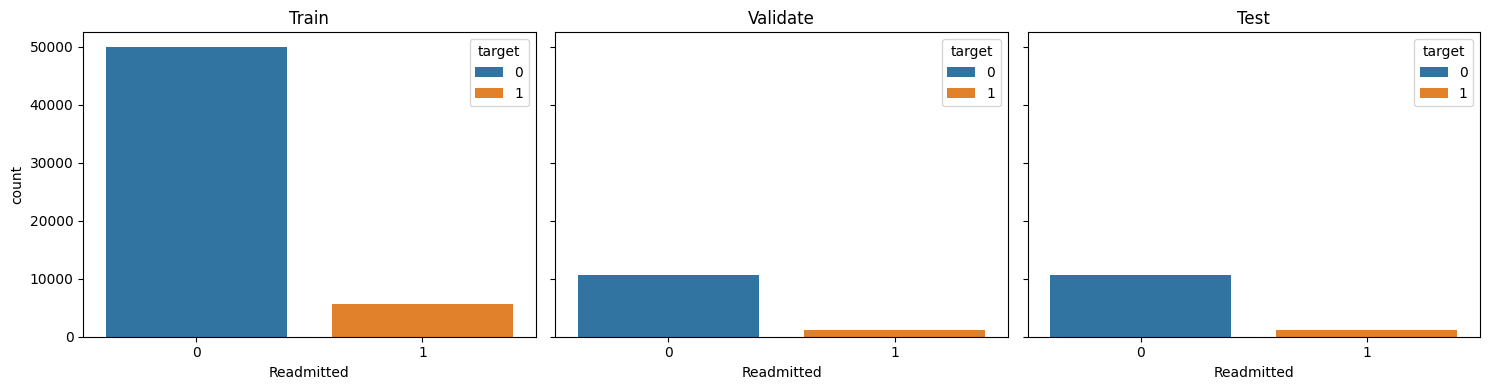

In [8]:
model = 'sgd' #SGDClassifier


sgd_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    model=model,
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True,
    one_hot_ordinal=True
)



### Feature Importance

In [9]:
if not PCA and SHOW_FEAT_IMPORTANCE:
    sgd_pipe.permute_importance()

### Baseline

In [10]:
if SHOW_FEAT_IMPORTANCE:
    sgd_pipe.run_baseline() # all true

### Hyperparameter Search

In [11]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    sgd_param_grid = {
        "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
        "model__penalty": ["l2", "l1", "elasticnet"],
        "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
        "model__l1_ratio": [0.1, 0.5, 0.9],
        "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
        "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
        "model__max_iter": [100, 500, 1000],
        "model__tol": [1e-3, 1e-4],
        "model__class_weight": [None, "balanced"],
        "model__average": [False, True, 5, 10],
        "model__shuffle": [True],
    }

    sgd_pipe.run_hyperparam_search(hyperparam_dist=sgd_param_grid)

### Validate

In [12]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    sgd_pipe.validate(
        show_duration_info=True,
        use_local_model=True,
        tol=.0001,
        shuffle=True,
        penalty='l1',
        max_iter=500,
        loss='modified_huber',
        learning_rate='invscaling',
        l1_ratio=0.9,
        eta0=.003,
        class_weight=None,
        average=10,
        alpha=.001
        )
else:
    sgd_pipe.validate(show_duration_info=False)

Held out validation metrics: sgd
ROC_AUC:     0.6419034144582836
Accuracy:      0.6640053786032439
F1 score:      0.23992395437262357
Precision:     0.15572556762092793
Recall:        0.5223509933774835

Confusion matrix:

TN: 7270, FP: 3421, FN: 577, TP: 631

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.68      0.78     10691
           1       0.16      0.52      0.24      1208

    accuracy                           0.66     11899
   macro avg       0.54      0.60      0.51     11899
weighted avg       0.85      0.66      0.73     11899

Duration: 0 hrs, 0 mins, 1.5 secs


### Test

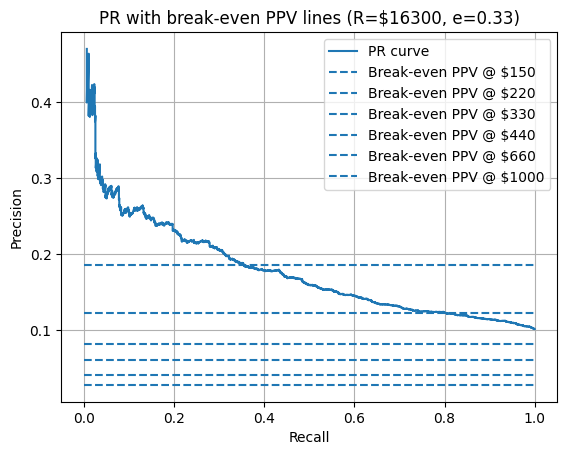

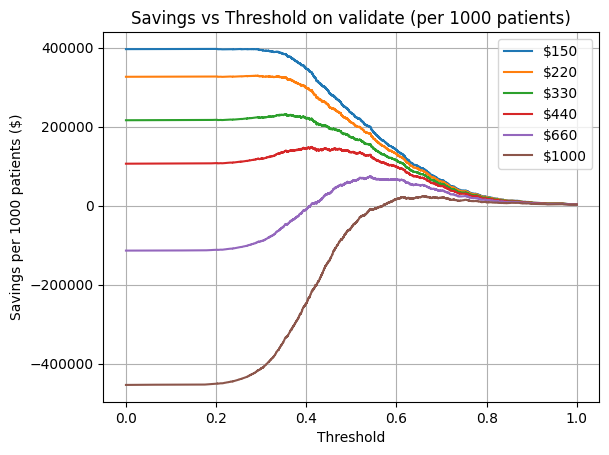

[COST] Chosen threshold: 0.3539 | PPV=0.112  Recall=0.935  FlagRate=0.844  Savings@$330=231.76 per patient
ROC_AUC:     0.6694076551501689
Accuracy:      0.24402398851254328
F1 score:      0.19136248644741596
Precision:     0.10678632651003328
Recall:        0.9200695047784535

Confusion matrix:

TN: 1830, FP: 8858, FN: 92, TP: 1059

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.17      0.29     10688
           1       0.11      0.92      0.19      1151

    accuracy                           0.24     11839
   macro avg       0.53      0.55      0.24     11839
weighted avg       0.87      0.24      0.28     11839

Duration: 0 hrs, 0 mins, 0.6 secs


In [13]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    sgd_pipe.test(
        use_f2_threshold=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        show_duration_info=True,
        use_local_model=True,
        tol=.0001,
        shuffle=True,
        penalty='l1',
        max_iter=500,
        loss='modified_huber',
        learning_rate='invscaling',
        l1_ratio=0.9,
        eta0=.003,
        class_weight=None,
        average=10,
        alpha=.001
    )

else:


    sgd_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=False,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

# Support Vector Classifier

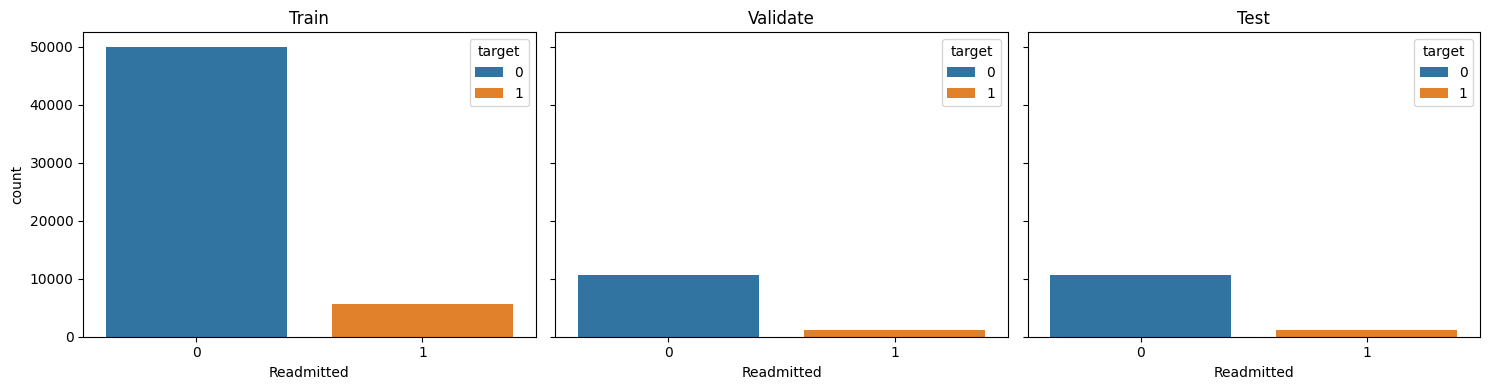

In [14]:

svc_pipe = ModelPipeline(
    model='svc',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True,
    one_hot_ordinal=True
)

### Baseline

In [15]:
if GET_BASELINE:
    svc_pipe.run_baseline(run_smote=False) # smote did not complete after ~6 hours

### Feature Importance

In [16]:
# slow
# svc_pipe.permute_importance()

### Hyperparameter Search

In [17]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    from scipy.stats import loguniform
    # slow

    # limited param search due to computation time
    svc_param_grid = {
        "model__C": loguniform(1e-3, 1e3),
        "model__gamma": [0.0001, 0.001, 0.01, 0.1, 1],     
    }

    svc_pipe.run_hyperparam_search(hyperparam_dist=svc_param_grid)

### Validate

In [18]:
if USE_PRE_COMPUTED_HYPERPARAMS:
        svc_pipe.validate(
        use_local_model=True,
        C=2.3973382079286494,
        gamma=.001
    )
else:
    svc_pipe.validate()

Held out validation metrics: svc
ROC_AUC:     0.6411854744443708
Accuracy:      0.7122447264476006
F1 score:      0.24714160070360597
Precision:     0.16826347305389222
Recall:        0.4652317880794702

Confusion matrix:

TN: 7913, FP: 2778, FN: 646, TP: 562

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.74      0.82     10691
           1       0.17      0.47      0.25      1208

    accuracy                           0.71     11899
   macro avg       0.55      0.60      0.53     11899
weighted avg       0.85      0.71      0.76     11899



### Test

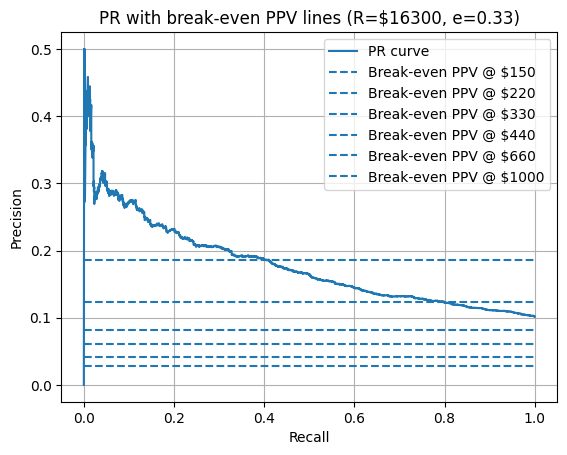

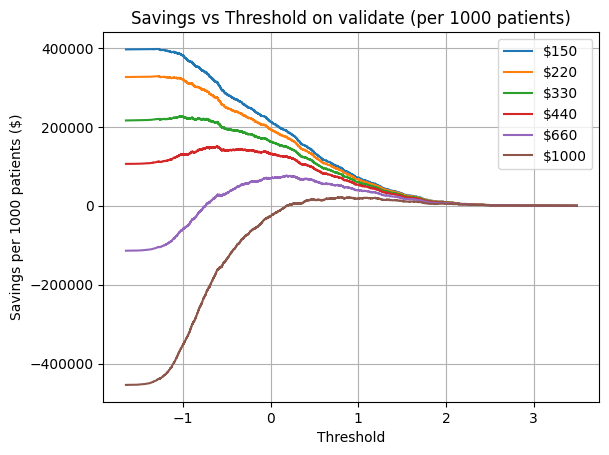

[COST] Chosen threshold: -1.0260 | PPV=0.109  Recall=0.946  FlagRate=0.878  Savings@$330=226.83 per patient
ROC_AUC:     0.6741491224761598
Accuracy:      0.2174170115719233
F1 score:      0.1901931649331352
Precision:     0.10573372206025267
Recall:        0.945264986967854

Confusion matrix:

TN: 1486, FP: 9202, FN: 63, TP: 1088

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.14      0.24     10688
           1       0.11      0.95      0.19      1151

    accuracy                           0.22     11839
   macro avg       0.53      0.54      0.22     11839
weighted avg       0.88      0.22      0.24     11839



In [19]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    svc_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        use_local_model=True,
        C=2.3973382079286494,
        gamma=.001
    )
else:
    svc_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

# XGBoost

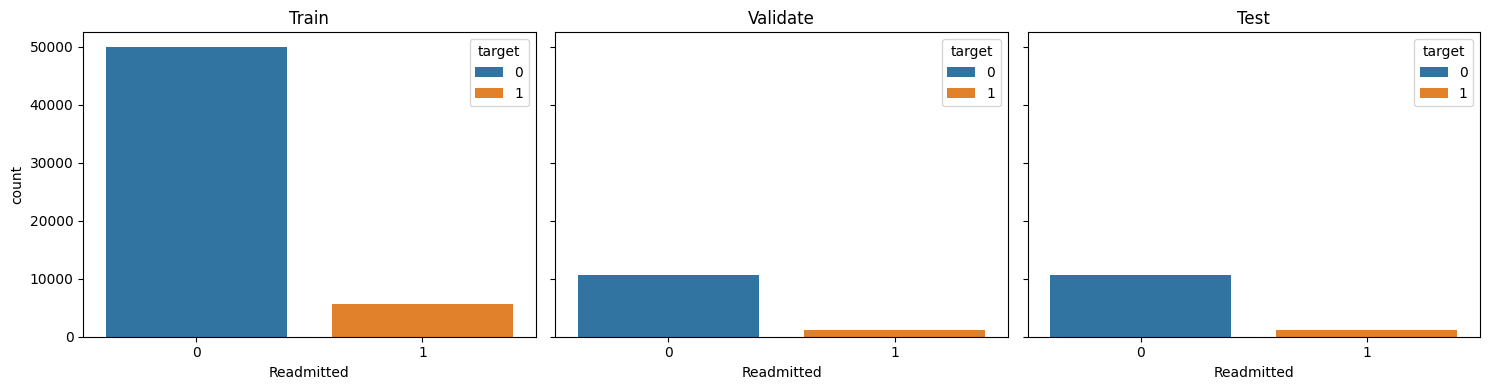

In [20]:
xgb_pipe = ModelPipeline(
    model='xgb',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log=UPDATE_DATABASE,
    create_interactions=False,
    log_transform_cols=np.array([]),
    use_pca=PCA,
    scaler=None,
    one_hot_ordinal=False,
    resample=False # handled by hyperparameters
)

In [21]:
if GET_BASELINE:
    xgb_pipe.run_baseline()

In [22]:
if not PCA and SHOW_FEAT_IMPORTANCE:
    xgb_pipe.permute_importance()

In [23]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    param_dist = {
        'model__max_depth': [3,4,5],
        'model__min_child_weight': [1,2,4],
        'model__subsample': [0.6,0.8,1.0],
        'model__colsample_bytree': [0.6,0.8,1.0],
        'model__gamma': [0,1,3],
        'model__learning_rate': [0.02, 0.05, 0.1],
        'model__scale_pos_weight': [1,2,4,6,8,10]
    }

    xgb_pipe.run_hyperparam_search(
        hyperparam_dist=param_dist
    )

In [24]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    xgb_pipe.validate(
        use_local_model=True,
        subsample=0.6,
        scale_pos_weight=4,
        min_child_weight=2,
        max_depth=3,
        learning_rate = 0.1,
        gamma = 0,
        colsample_bytree=0.8
    )
else:
    xgb_pipe.validate()

Held out validation metrics: xgb
ROC_AUC:     0.6437720174981617
Accuracy:      0.8701571560635347
F1 score:      0.1889763779527559
Precision:     0.2582496413199426
Recall:        0.1490066225165563

Confusion matrix:

TN: 10174, FP: 517, FN: 1028, TP: 180

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93     10691
           1       0.26      0.15      0.19      1208

    accuracy                           0.87     11899
   macro avg       0.58      0.55      0.56     11899
weighted avg       0.84      0.87      0.85     11899



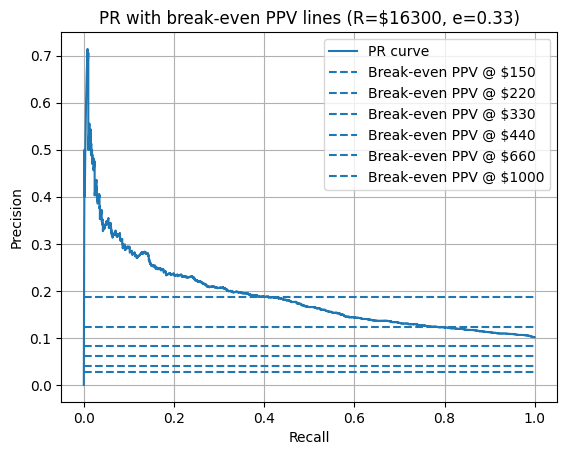

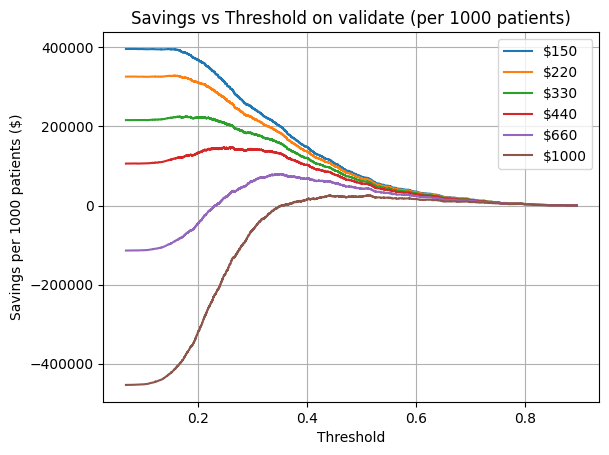

[COST] Chosen threshold: 0.1797 | PPV=0.108  Recall=0.951  FlagRate=0.891  Savings@$330=225.35 per patient
ROC_AUC:     0.6760256637030024
Accuracy:      0.20897035222569474
F1 score:      0.1893880377391154
Precision:     0.10517208229186695
Recall:        0.950477845351868

Confusion matrix:

TN: 1380, FP: 9308, FN: 57, TP: 1094

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.13      0.23     10688
           1       0.11      0.95      0.19      1151

    accuracy                           0.21     11839
   macro avg       0.53      0.54      0.21     11839
weighted avg       0.88      0.21      0.22     11839



In [25]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    xgb_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        use_local_model=True,
        subsample=0.6,
        scale_pos_weight=4,
        min_child_weight=2,
        max_depth=3,
        learning_rate = 0.1,
        gamma = 0,
        colsample_bytree=0.8
    )

else:

    xgb_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=False,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

In [26]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    import matplotlib.pyplot as plt
    from shared_util.dataio import load_csv



    df = load_csv('cleaned')
    from shared_util.split import group_split

    X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)
    plt.hist(xgb_pipe.randomized_search.best_estimator_.predict_proba(X_validate)[:,1], bins=50) #type: ignore
    plt.show()
